In [144]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import glob
from pyproj import CRS#, Transformer
from land_wavelet import wclass
from matplotlib.patches import Rectangle

In [2]:
cd ..

/users/global/cornkle/pythonWorkspace/proj_CEH


In [52]:
da_box = xr.open_dataset('/users/global/cornkle/shared/data/OBS/hansen_0pt05/global_percent_forest_loss_0pt05deg.nc')

In [51]:
# Open multiple files and add a "month" coordinate from filenames
ds = xr.open_mfdataset('/users/global/cornkle/shared/data/LST_trend_global/LSTtrend_scales_perMonth_POSITIVE_*.nc', concat_dim="month", combine="nested")

# Assign a month coordinate (assuming filenames are sequentially numbered)
ds = ds.assign_coords(month=np.arange(1, 13))

In [46]:
# da_box = da_box.sel(lat=slice(-60,70))
# ds = ds.sel(lat=slice(-60,70))

In [53]:
da_box

<xarray.Dataset>
Dimensions:            (lat: 3600, lon: 7200)
Coordinates:
  * lat                (lat) float32 -89.97 -89.93 -89.88 ... 89.88 89.93 89.97
  * lon                (lon) float32 -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    forest_cover_loss  (lat, lon) float32 ...
Attributes:
    description:  Percentage net loss of global forest coverage from 2000-201...
    history:      Created 20/04/21

In [54]:
ds

<xarray.Dataset>
Dimensions:  (scales: 15, lon: 7200, lat: 3600, month: 12)
Coordinates:
  * scales   (scales) float64 15.0 19.79 26.12 34.46 ... 316.7 417.9 551.4 727.5
  * lon      (lon) float32 -180.0 -179.9 -179.9 -179.9 ... 179.9 179.9 179.9
  * lat      (lat) float32 -90.0 -89.95 -89.9 -89.85 ... 89.8 89.85 89.9 89.95
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    power_y  (month, scales, lon, lat) float64 dask.array<chunksize=(1, 15, 7200, 3600), meta=np.ndarray>
    power_x  (month, scales, lon, lat) float64 dask.array<chunksize=(1, 15, 7200, 3600), meta=np.ndarray>
    trend    (month, lon, lat) float32 dask.array<chunksize=(1, 7200, 3600), meta=np.ndarray>

In [153]:
maxs = ds['trend'].max('month').T
both = maxs.where((maxs.values>=0.1) & (da_box['forest_cover_loss'].values>=10))

In [154]:
LST_and_forest = both>0

In [155]:
forest_only = (da_box['forest_cover_loss'].values>=10).astype(int)

In [156]:
da_box.lon

<xarray.DataArray 'lon' (lon: 7200)>
array([-179.975, -179.925, -179.875, ...,  179.875,  179.925,  179.975],
      dtype=float32)
Coordinates:
  * lon      (lon) float32 -180.0 -179.9 -179.9 -179.8 ... 179.9 179.9 180.0
Attributes:
    standard_name:  lon
    long_name:      longitude
    units:          degrees_east

In [157]:
wObj = wclass.landwav('deforest')

Initialised wavelet with scales:  [  5.           6.59753955   8.70550563  11.48698355  15.15716567
  20.          26.39015822  34.82202253  45.9479342   60.62866266
  80.         105.56063286 139.28809013 183.7917368  242.51465064
 320.        ]


In [158]:
### The next step prepares the SM image for the wavelet routine. NaNs are removed by filling in zeros that can be masked again after wavelet application.
wObj.read_img(forest_only, da_box.lon.values, da_box.lat.values)

Mean res is 0.05  I found that grid is not regular. If in doubt, please check.


In [159]:
# We now apply the wavelet scale decomposition to the image as defined in the wObj object. This step saves wavelet coefficients and powers to the object.
# The resulting powers could be used for diverse analyses.

coeffs, power, scales, period = wObj.applyWavelet(normed='stddev', ge_thresh=None, le_thresh=0, fill=0.01)

Wavelet coeffs (none or stddev) and power (none, stddev or scale) normed by: stddev Please note: Choose none if value reconstruction is intended.


In [160]:
# Compute the indices of the max scale in memory
max_scale_idx_x = np.argmax(power, axis=0)

In [161]:
max_scale_idx_x.shape

(3600, 7200)

In [162]:
# Use these indices to extract the corresponding scale values
max_scale_x = scales[max_scale_idx_x]

In [163]:
max_scale_x.shape

(3600, 7200)

In [164]:
deforest_200 = ((max_scale_x >= 50) & (max_scale_x <= 200) & forest_only==1).astype(int)

/users/global/cornkle/miniconda3/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


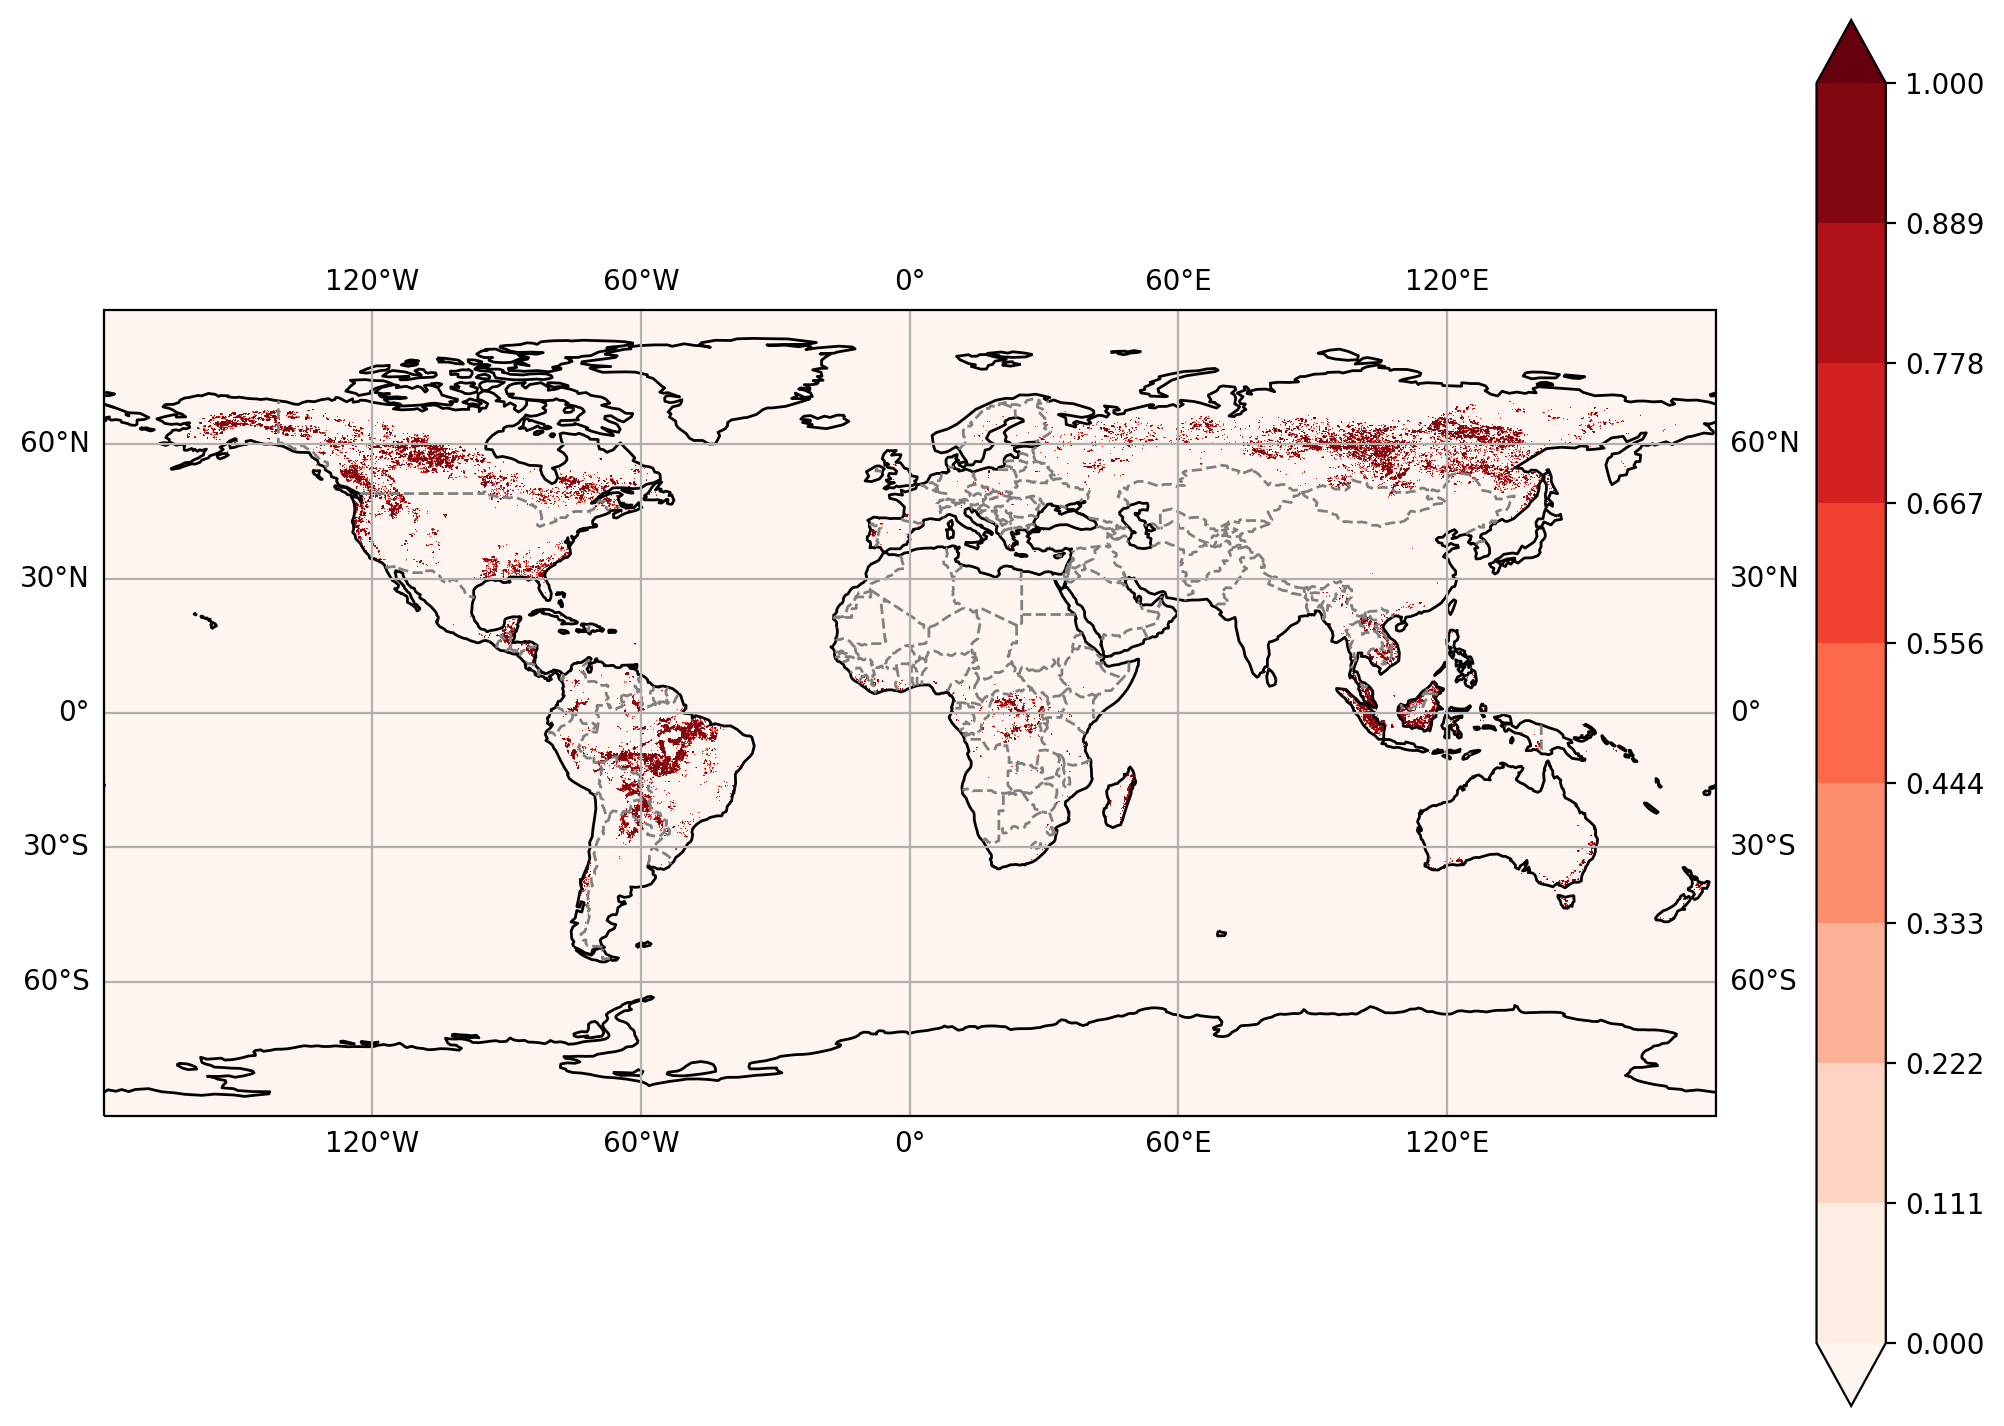

In [92]:
f = plt.figure(figsize=(13,9), dpi=200)
ax = f.add_subplot(111, projection=ccrs.PlateCarree())
plt.contourf(da_box.lon.values, da_box.lat.values, LST_and_forest, transform=ccrs.PlateCarree(), cmap='Reds', extend='both', levels=np.linspace(0,1,10))
ax.coastlines()

xl = ax.gridlines(draw_labels=True);

# Countries
ax.add_feature(cartopy.feature.BORDERS, linestyle='--', color='grey');

cbar = plt.colorbar()

In [62]:
# Compute the indices of the max scale in memory
max_scale_idx_x = (ds.power_x+ds.power_y).argmax(dim="scales").compute()
#max_scale_idx_y = ds.power_y.argmax(dim="scales").compute()

# Use these indices to extract the corresponding scale values
max_scale_x = ds.scales[max_scale_idx_x]
#max_scale_y = ds.scales[max_scale_idx_y]

In [64]:
np.unique(max_scale_x)

array([ 15.        ,  19.79261866,  26.1165169 ,  34.46095065,
        45.471497  ,  60.        ,  79.17047465, 104.4660676 ,
       137.8438026 , 181.88598798, 240.        , 316.68189859,
       417.86427038, 551.3752104 , 727.54395192])

In [85]:
# Check if max scale falls in the 100-200 km range for each month
valid_months = (max_scale_x >= 50) & (max_scale_x <= 200)
#valid_y = (max_scale_y >= 100) & (max_scale_y <= 200)

# Combine both conditions
#valid_months = valid_x | valid_y  # Boolean array (True if condition met for each month)

# Count how many months meet the condition per pixel
count_valid_months = valid_months.sum(dim="month")

# Create binary map (1 if at least 3 months meet condition, 0 otherwise)
scale_LST200km = (count_valid_months >= 6).astype(int)

/users/global/cornkle/miniconda3/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


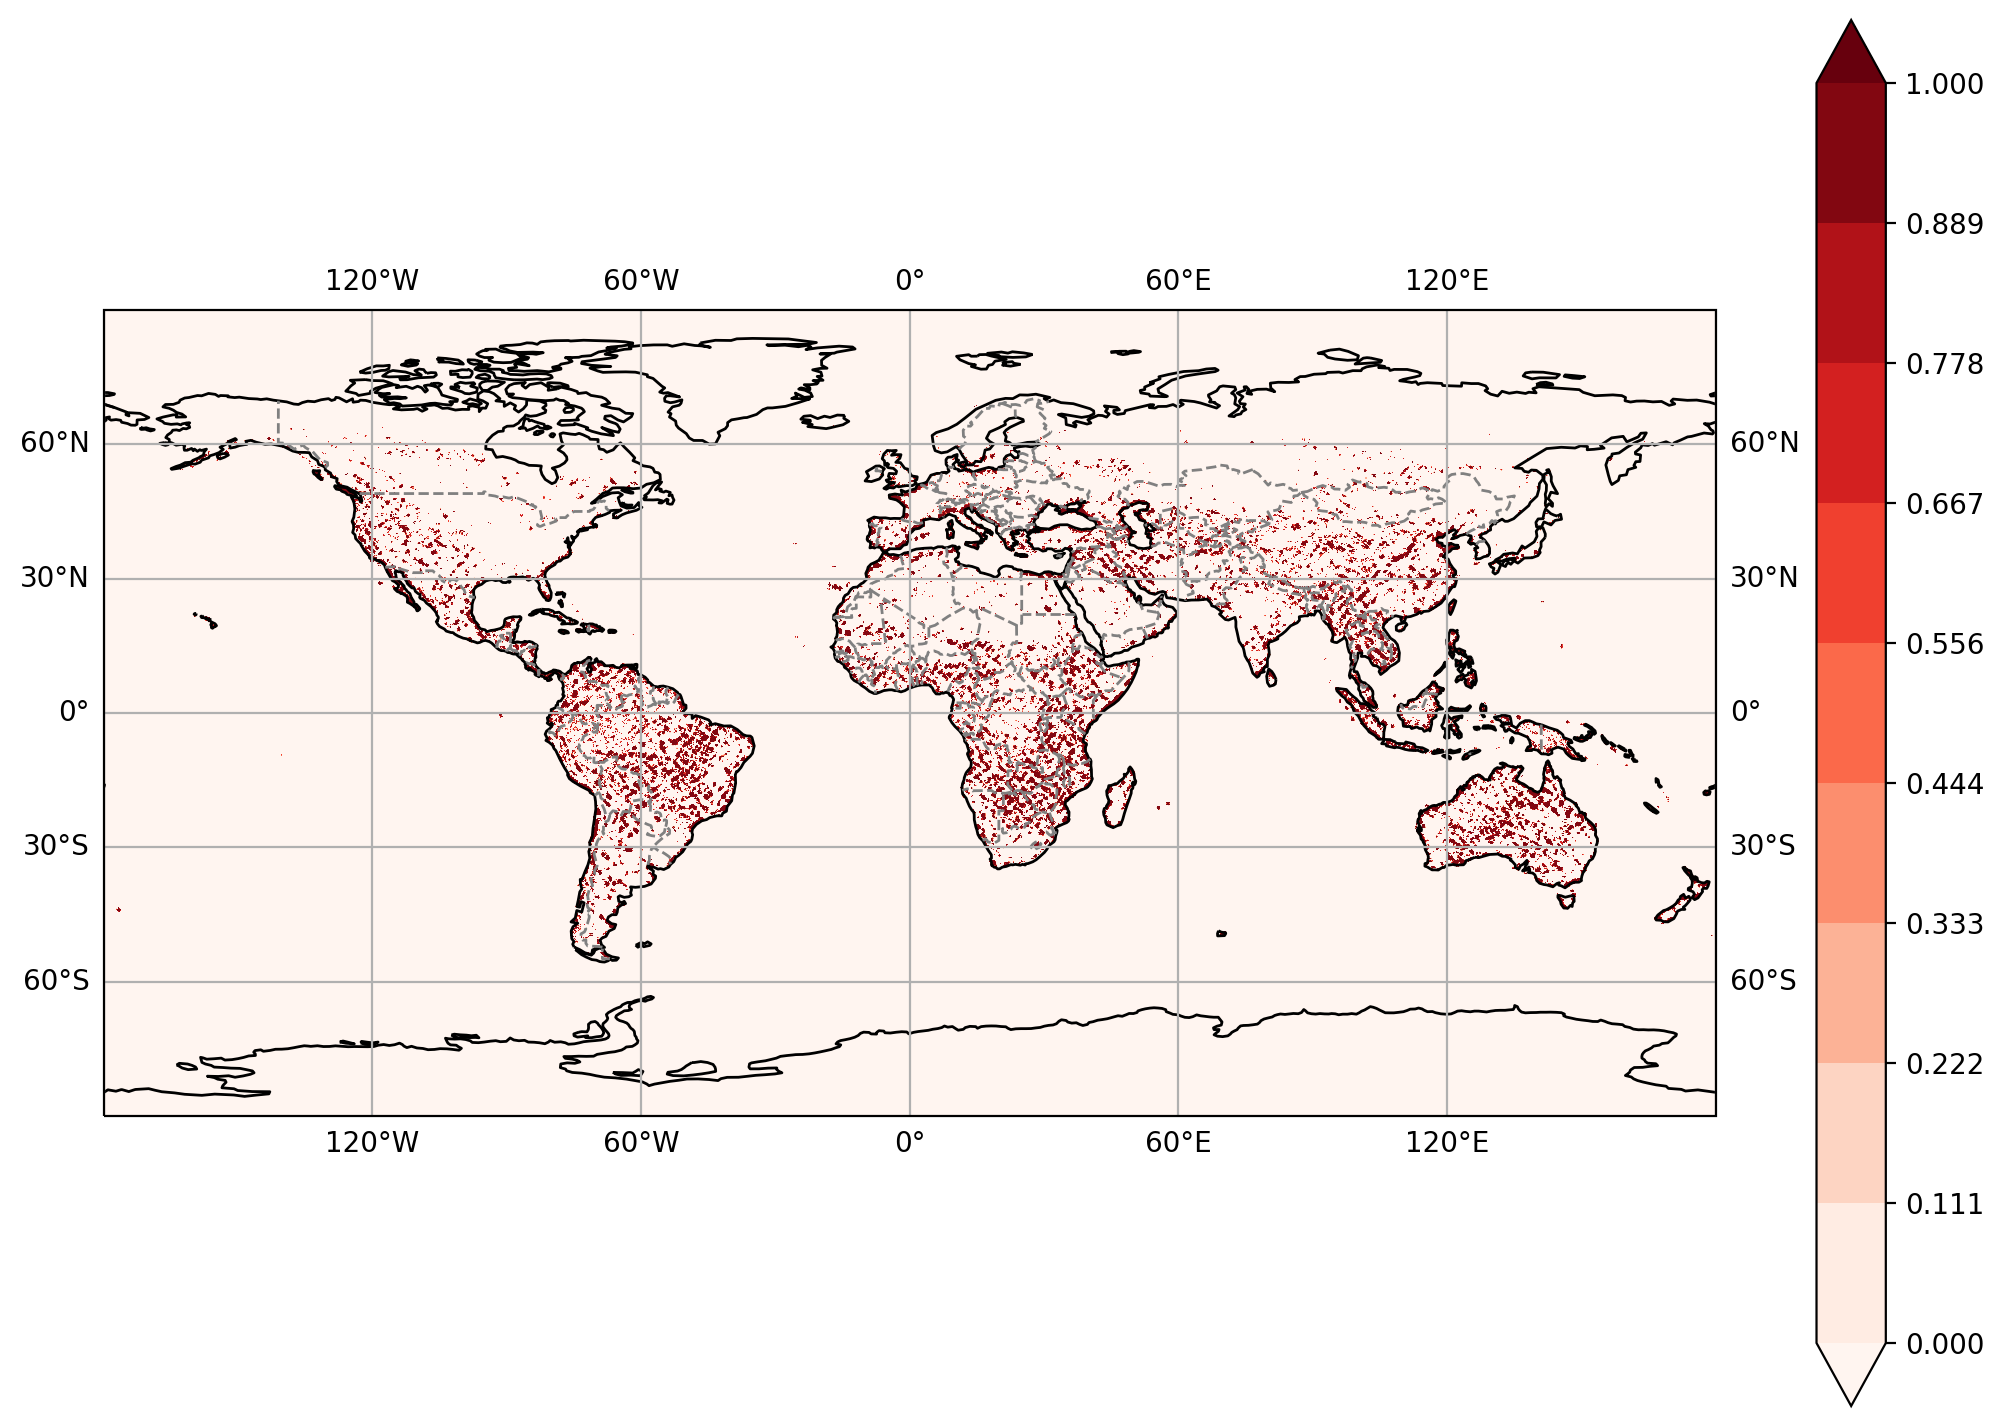

In [86]:
f = plt.figure(figsize=(13,9), dpi=200)
ax = f.add_subplot(111, projection=ccrs.PlateCarree())
plt.contourf(da_box.lon.values, da_box.lat.values, scale_LST200km.T, transform=ccrs.PlateCarree(), cmap='Reds', extend='both', levels=np.linspace(0,1,10))
ax.coastlines()

xl = ax.gridlines(draw_labels=True);

# Countries
ax.add_feature(cartopy.feature.BORDERS, linestyle='--', color='grey');

cbar = plt.colorbar()

In [109]:
forest_and_200kmLST = ((maxs.values>=0.1) & (scale_LST200km.T==1) & (da_box['forest_cover_loss'].values>=25)).astype(int)

/users/global/cornkle/miniconda3/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


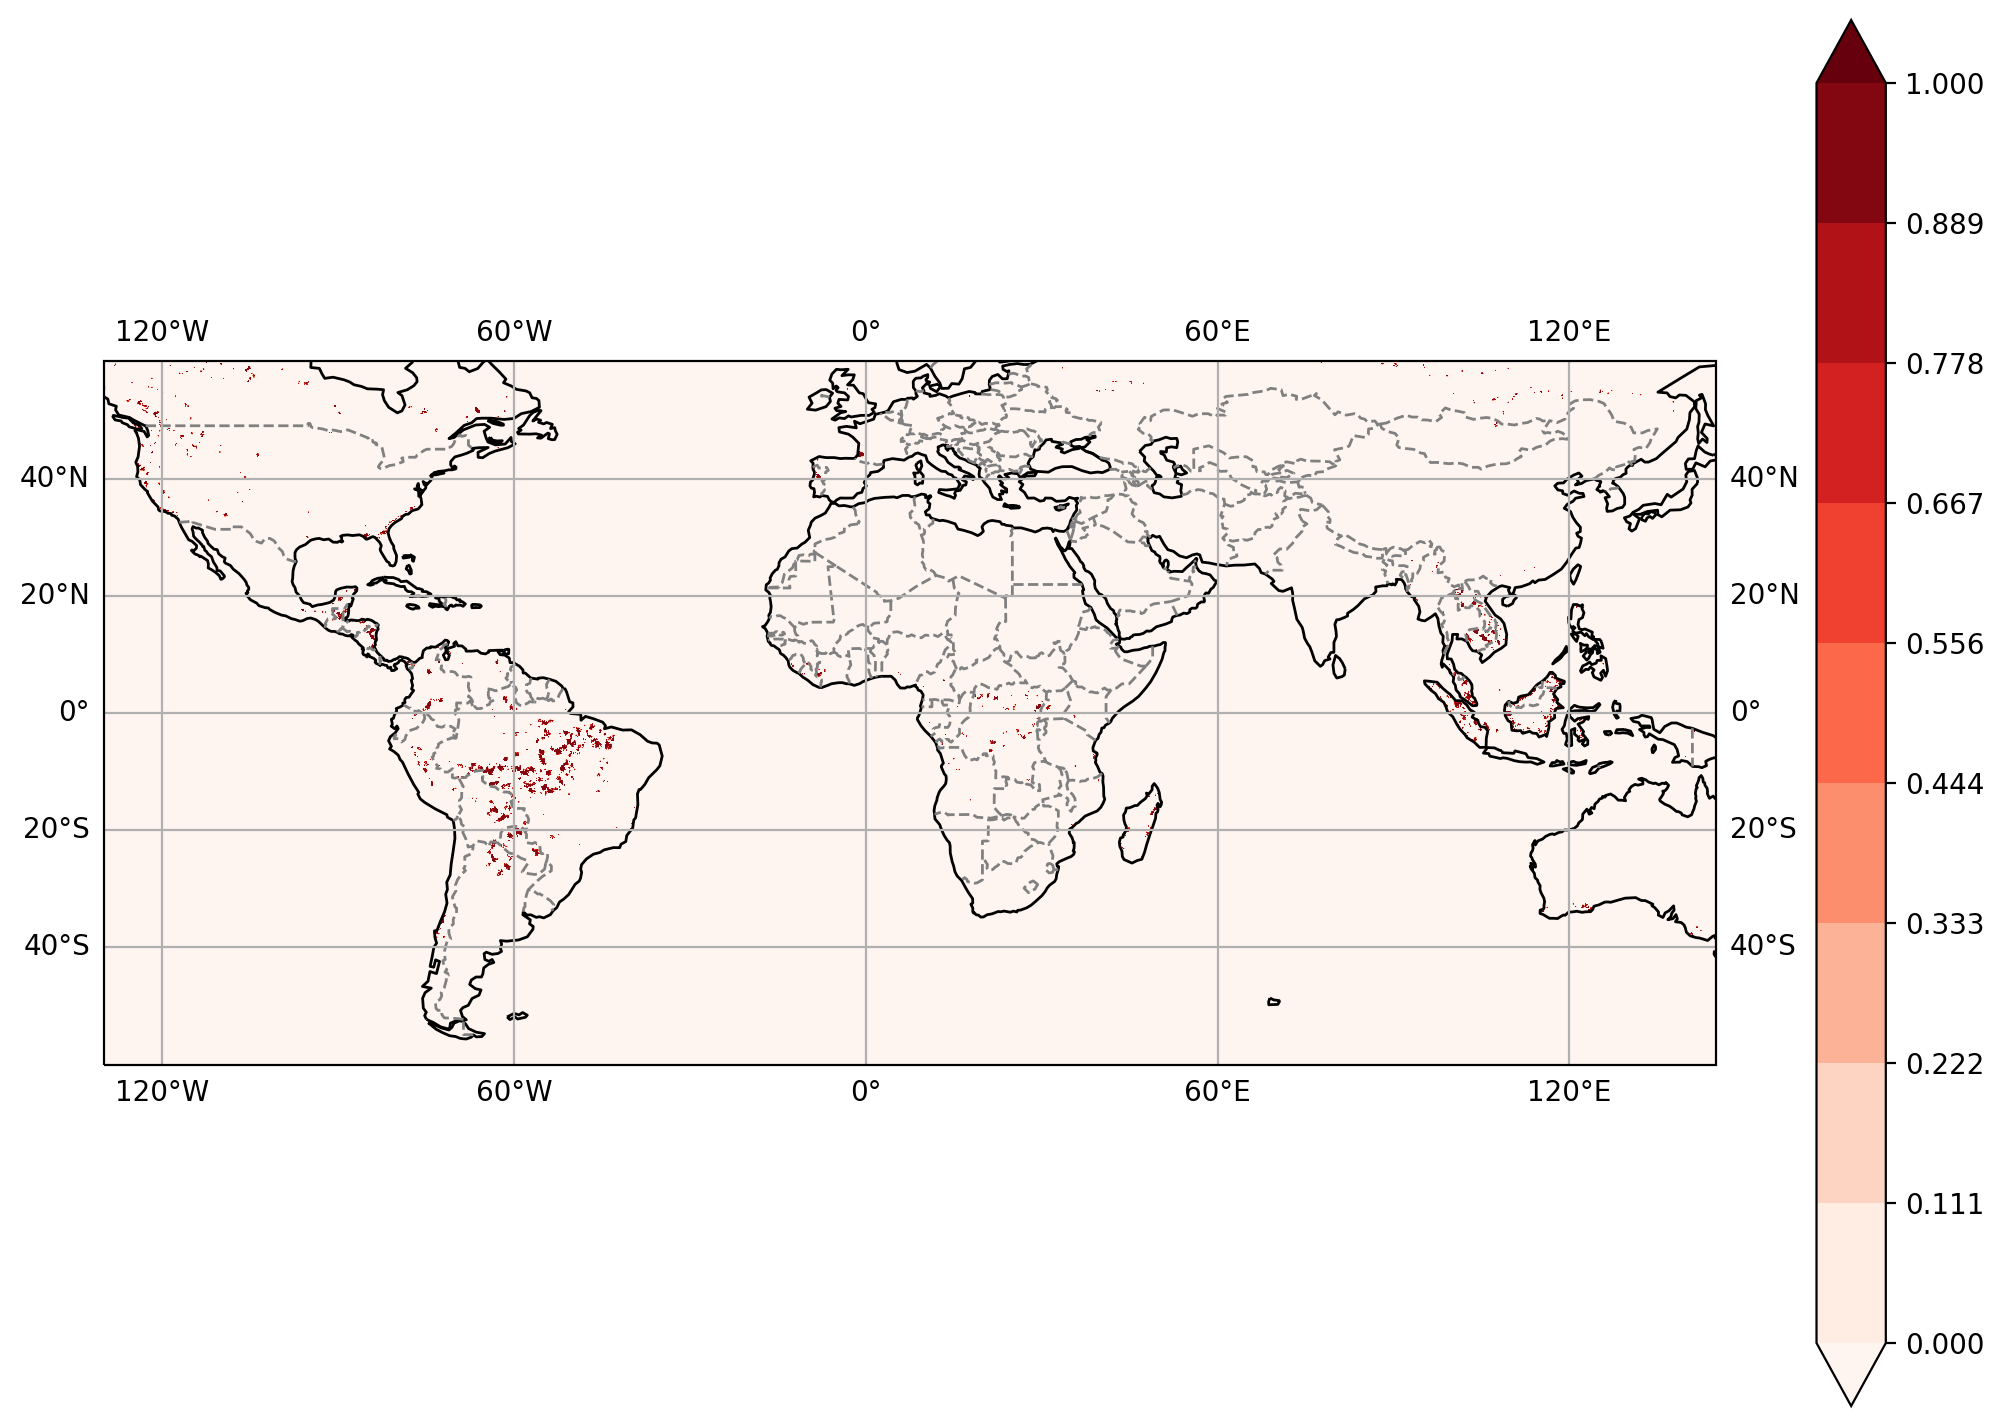

In [107]:
f = plt.figure(figsize=(13,9), dpi=200)
ax = f.add_subplot(111, projection=ccrs.PlateCarree())
plt.contourf(da_box.lon.values, da_box.lat.values, forest_and_200kmLST, transform=ccrs.PlateCarree(), cmap='Reds', extend='both', levels=np.linspace(0,1,10))
ax.coastlines()

xl = ax.gridlines(draw_labels=True);

# Countries
ax.add_feature(cartopy.feature.BORDERS, linestyle='--', color='grey');
ax.set_ylim(-60,60)
ax.set_xlim(-130,145)
cbar = plt.colorbar()

/users/global/cornkle/miniconda3/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


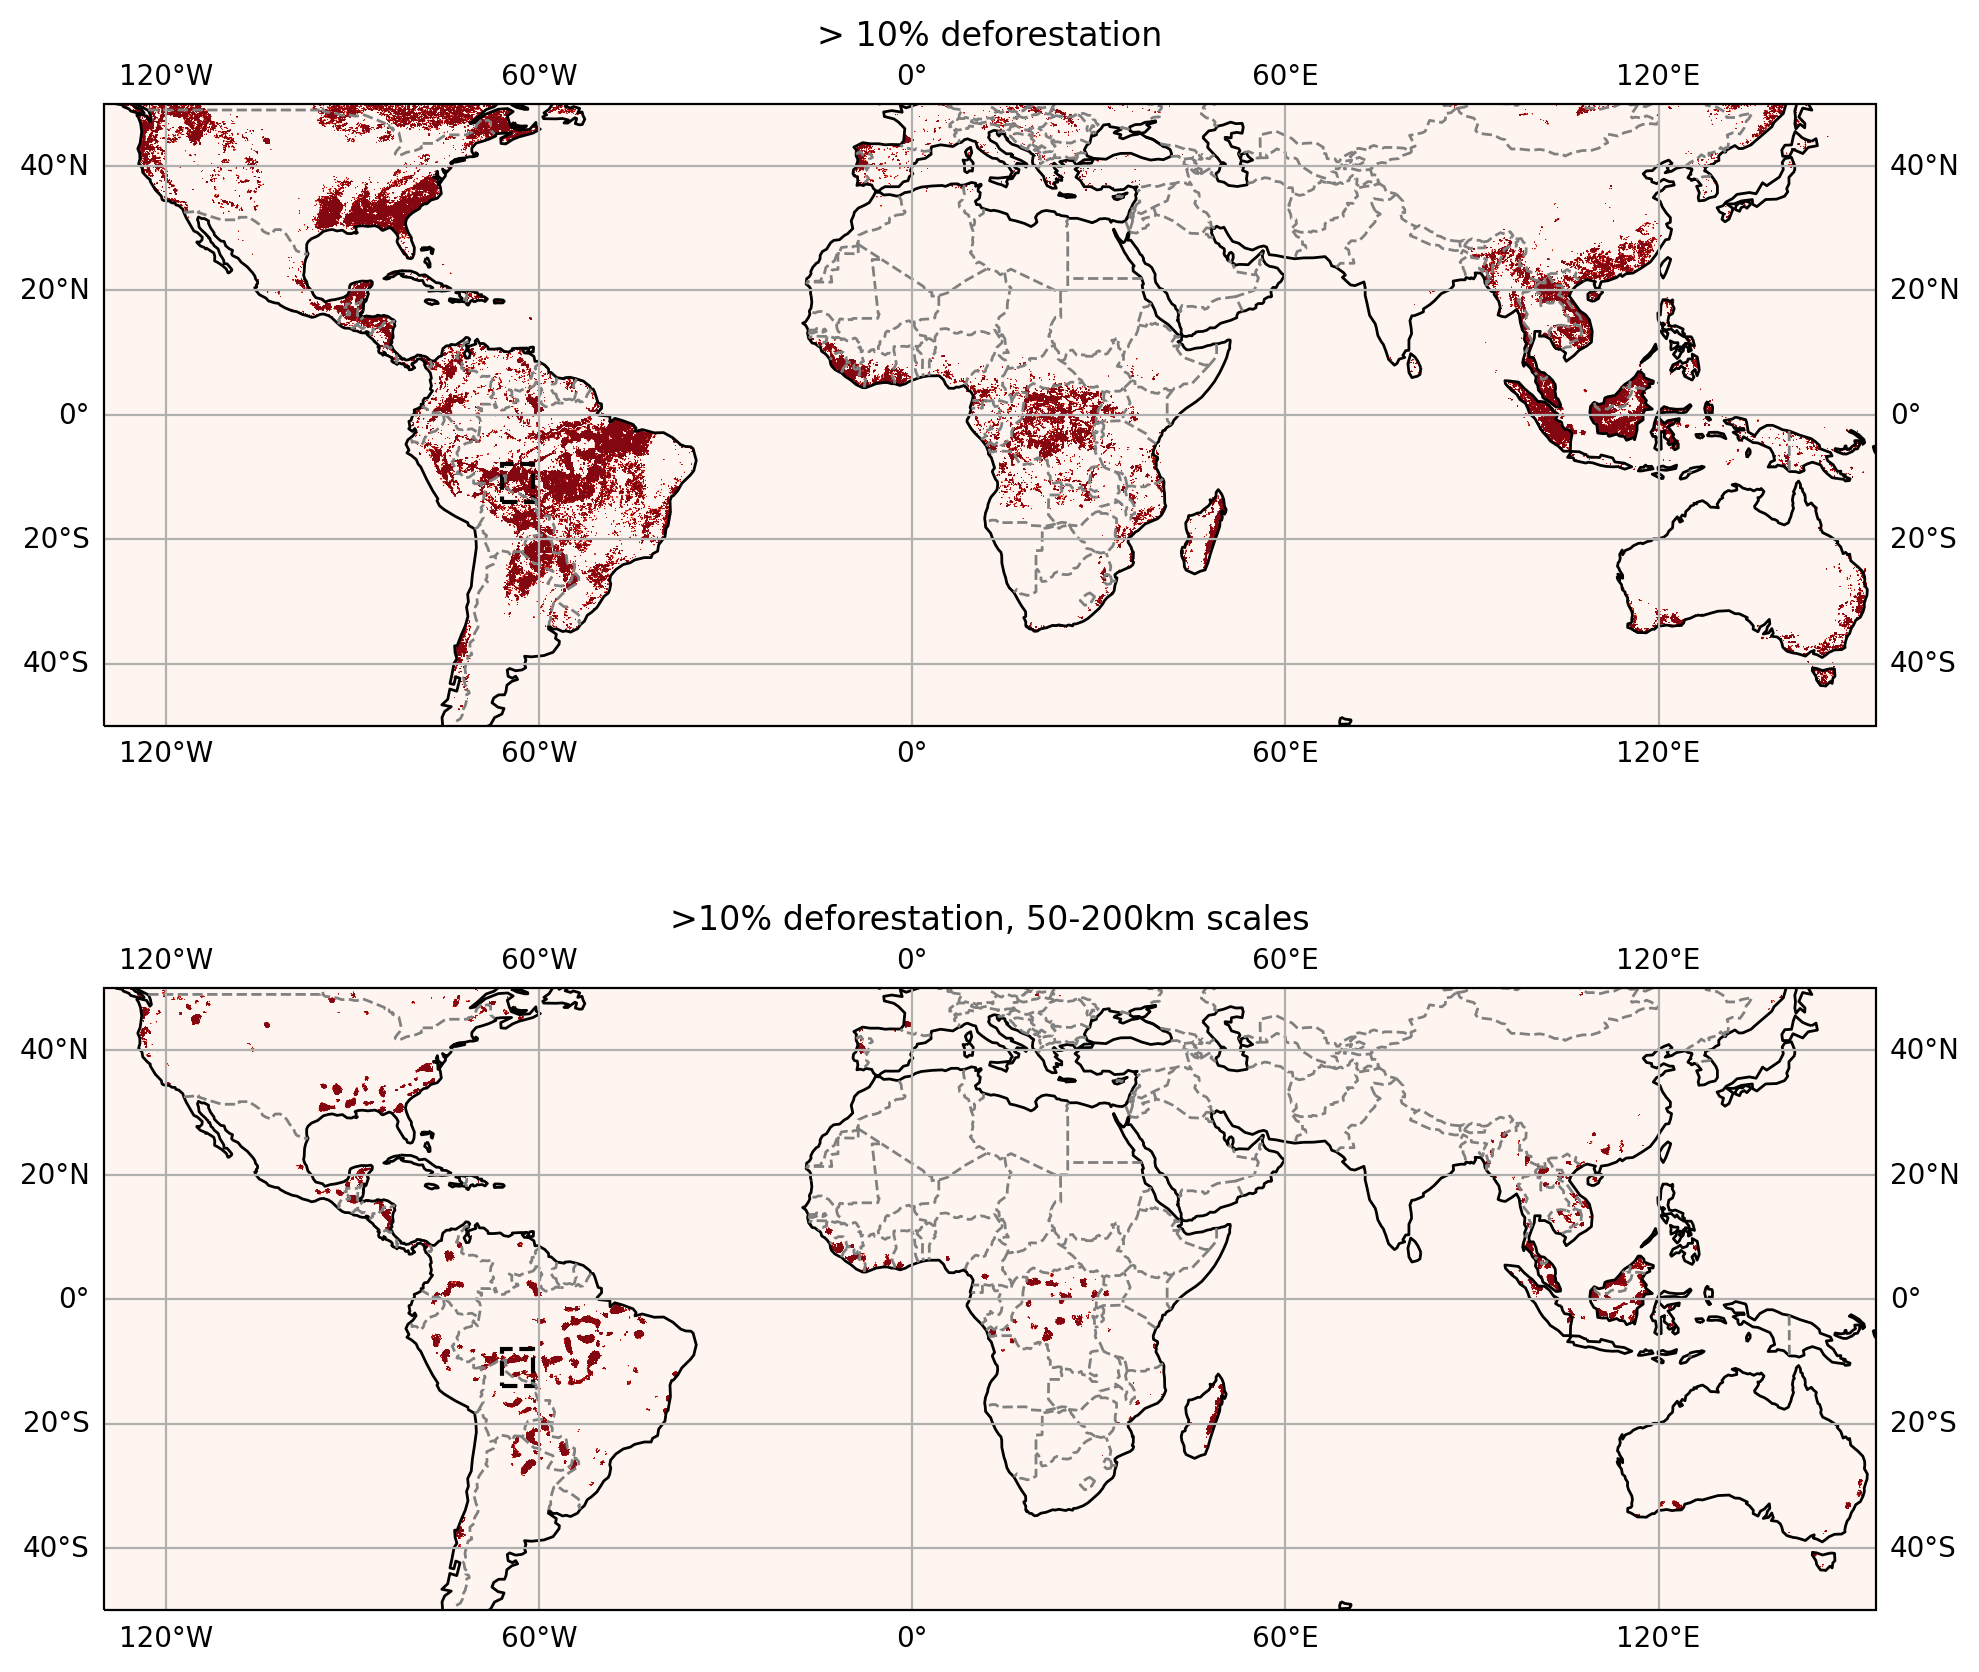

In [172]:
# Define box coordinates (lat_min, lat_max, lon_min, lon_max)
lat_min, lat_max = -14, -8
lon_min, lon_max = -66, -61

# Calculate width and height
width = lon_max - lon_min
height = lat_max - lat_min

f = plt.figure(figsize=(10,9), dpi=200)
ax = f.add_subplot(211, projection=ccrs.PlateCarree())
plt.contourf(da_box.lon.values, da_box.lat.values, forest_only, transform=ccrs.PlateCarree(), cmap='Reds', extend='both', levels=np.linspace(0,1,10))
ax.coastlines()

xl = ax.gridlines(draw_labels=True);

# Countries
ax.add_feature(cartopy.feature.BORDERS, linestyle='--', color='grey');

plt.title('> 10% deforestation')
ax.set_ylim(-50,50)
ax.set_xlim(-130,155)

# Add a dashed-line rectangle
rect = Rectangle((lon_min, lat_min), width, height,
                 linewidth=1.5, edgecolor='black', linestyle="dashed", fill=False, transform=ccrs.PlateCarree())
ax.add_patch(rect)

#cbar = plt.colorbar()


ax = f.add_subplot(212, projection=ccrs.PlateCarree())
# plt.contourf(da_box.lon.values, da_box.lat.values, forest_and_200kmLST, transform=ccrs.PlateCarree(), cmap='Reds', extend='both', levels=np.linspace(0,1,10))
# ax.coastlines()

# xl = ax.gridlines(draw_labels=True);
# plt.title('>25% deforestation | > 0.1K/year temperature trend at 50-200km scale')

plt.contourf(da_box.lon.values, da_box.lat.values, deforest_200, transform=ccrs.PlateCarree(), cmap='Reds', extend='both', levels=np.linspace(0,1,10))
ax.coastlines()

xl = ax.gridlines(draw_labels=True);
plt.title('>10% deforestation, 50-200km scales')

# Countries
ax.add_feature(cartopy.feature.BORDERS, linestyle='--', color='grey');
ax.set_ylim(-50,50)
ax.set_xlim(-130,155)
#cbar = plt.colorbar()

# Add a dashed-line rectangle
rect = Rectangle((lon_min, lat_min), width, height,
                 linewidth=1.5, edgecolor='black', linestyle="dashed", fill=False, transform=ccrs.PlateCarree())
ax.add_patch(rect)


plt.tight_layout()
f.savefig('/users/global/cornkle/shared/figs/Edward_coldPool/deforestation_only_50-200km.jpg')

/users/global/cornkle/miniconda3/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


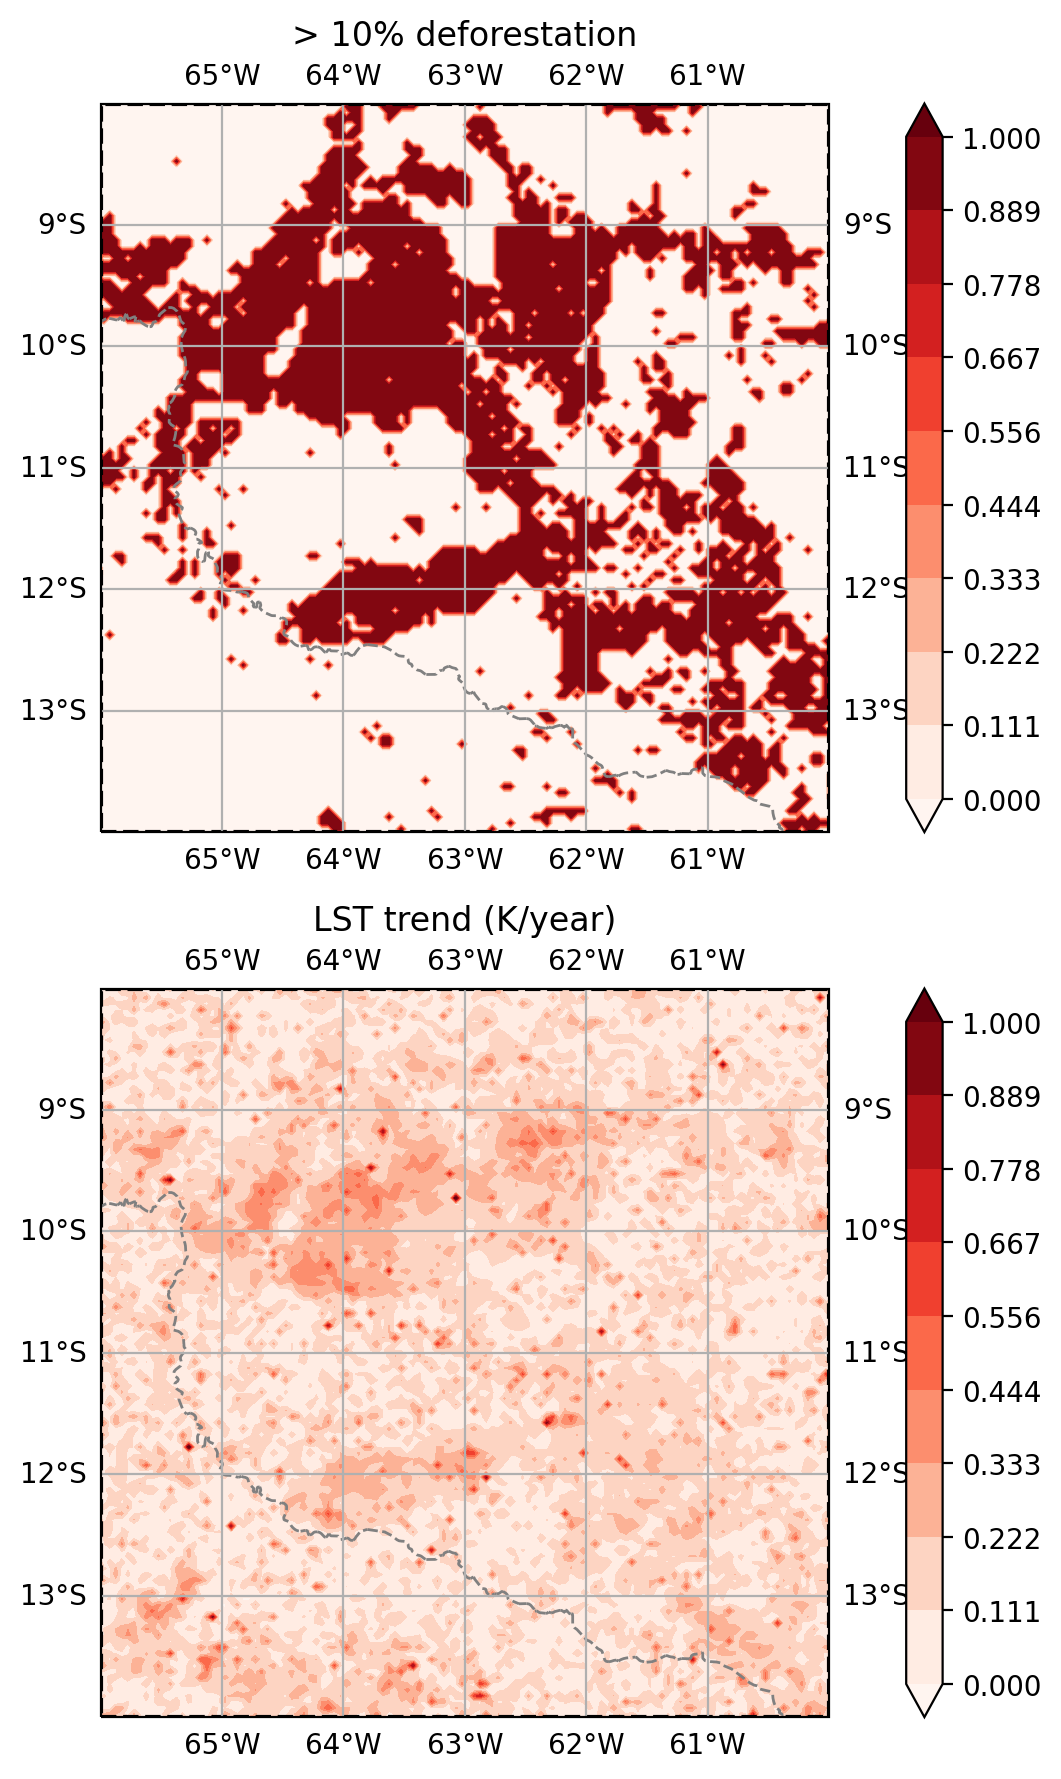

In [171]:
# Define box coordinates (lat_min, lat_max, lon_min, lon_max)
lat_min, lat_max = -14, -8
lon_min, lon_max = -66, -60

# Calculate width and height
width = lon_max - lon_min
height = lat_max - lat_min

f = plt.figure(figsize=(8,9), dpi=200)
ax = f.add_subplot(211, projection=ccrs.PlateCarree())
plt.contourf(da_box.lon.values, da_box.lat.values, (da_box['forest_cover_loss'].values>=10), transform=ccrs.PlateCarree(), cmap='Reds', extend='both', levels=np.linspace(0,1,10))
ax.coastlines()

xl = ax.gridlines(draw_labels=True);

# Countries
ax.add_feature(cartopy.feature.BORDERS, linestyle='--', color='grey');

plt.title('> 10% deforestation')
ax.set_ylim(lat_min,lat_max)
ax.set_xlim(lon_min,lon_max)

# Add a dashed-line rectangle
rect = Rectangle((lon_min, lat_min), width, height,
                 linewidth=1.5, edgecolor='black', linestyle="dashed", fill=False, transform=ccrs.PlateCarree())
ax.add_patch(rect)

cbar = plt.colorbar()


ax = f.add_subplot(212, projection=ccrs.PlateCarree())
# plt.contourf(da_box.lon.values, da_box.lat.values, forest_and_200kmLST, transform=ccrs.PlateCarree(), cmap='Reds', extend='both', levels=np.linspace(0,1,10))
# ax.coastlines()

# xl = ax.gridlines(draw_labels=True);
# plt.title('>25% deforestation | > 0.1K/year temperature trend at 50-200km scale')

plt.contourf(da_box.lon.values, da_box.lat.values, maxs, transform=ccrs.PlateCarree(), cmap='Reds', extend='both', levels=np.linspace(0,1,10))
ax.coastlines()

xl = ax.gridlines(draw_labels=True);
plt.title('LST trend (K/year)')

# Countries
ax.add_feature(cartopy.feature.BORDERS, linestyle='--', color='grey');
ax.set_ylim(lat_min,lat_max)
ax.set_xlim(lon_min,lon_max)
cbar = plt.colorbar()

# Add a dashed-line rectangle
rect = Rectangle((lon_min, lat_min), width, height,
                 linewidth=1.5, edgecolor='black', linestyle="dashed", fill=False, transform=ccrs.PlateCarree())
ax.add_patch(rect)


plt.tight_layout()
f.savefig('/users/global/cornkle/shared/figs/Edward_coldPool/zoom_box.jpg')